In [10]:
import pandas as pd
import numpy as np
import os
import zipfile
from google.colab import drive

In [11]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


--- PHASE 1: GRAVITY ALIGNMENT VERIFICATION ---
[UCI] Mean Gravity on X-axis: 1.019 m/s^2
Loading UCI Raw Data...
Loading MotionSense Raw Data (7 Activities)...
Fusing Datasets and Mapping 7 Labels...
Training Random Forest Classifier (7 Classes)...

Classification Report (7 Classes):
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      1300
           1       0.96      0.96      0.96       685
           2       0.97      0.95      0.96       588
           3       0.99      0.99      0.99      1302
           4       0.99      1.00      0.99      1218
           5       1.00      0.99      0.99       405
           6       1.00      0.99      1.00       281

    accuracy                           0.98      5779
   macro avg       0.98      0.98      0.98      5779
weighted avg       0.98      0.98      0.98      5779

✅ Confusion Matrix saved at: /content/drive/MyDrive/FINAL_EXPORT/RF_COMBINATION/confusion_matrix_7classes.png


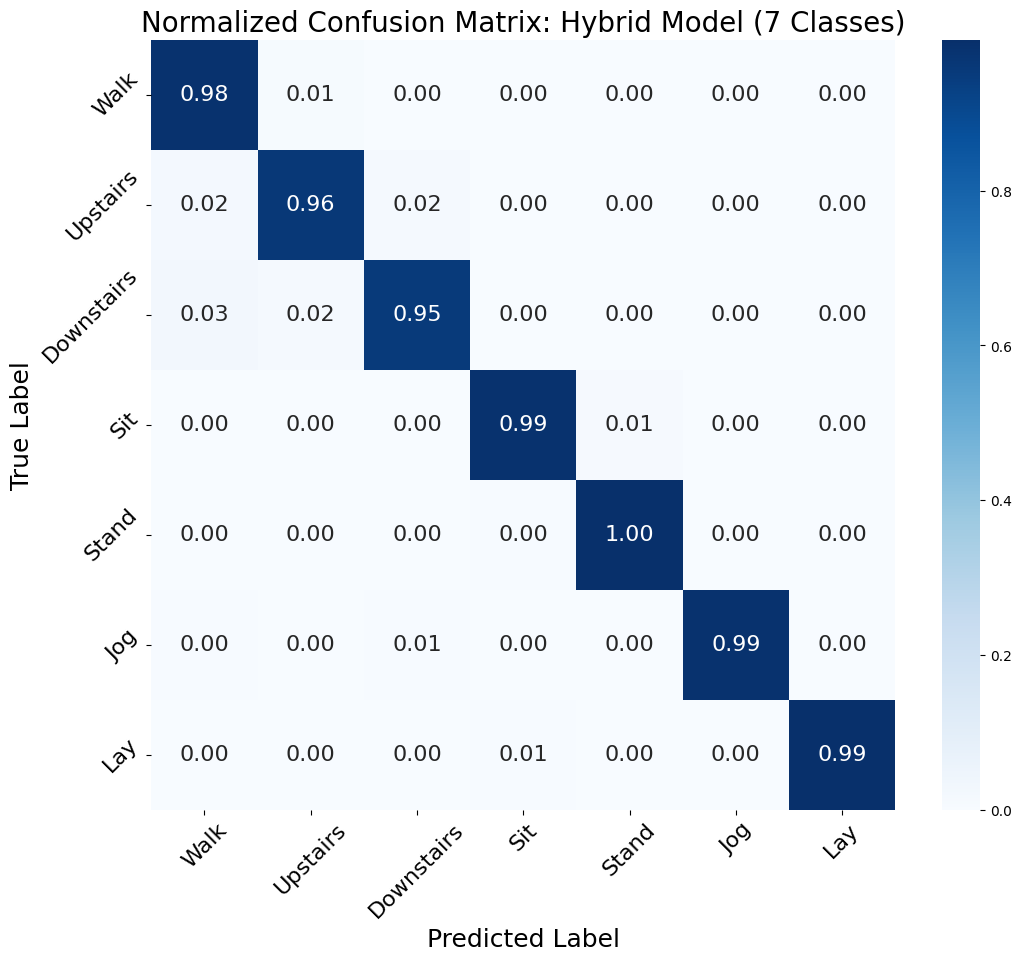

/tmp/ipykernel_9836/3563471405.py:211: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices[:20]], y=[feat_names[i] for i in indices[:20]], palette="viridis")


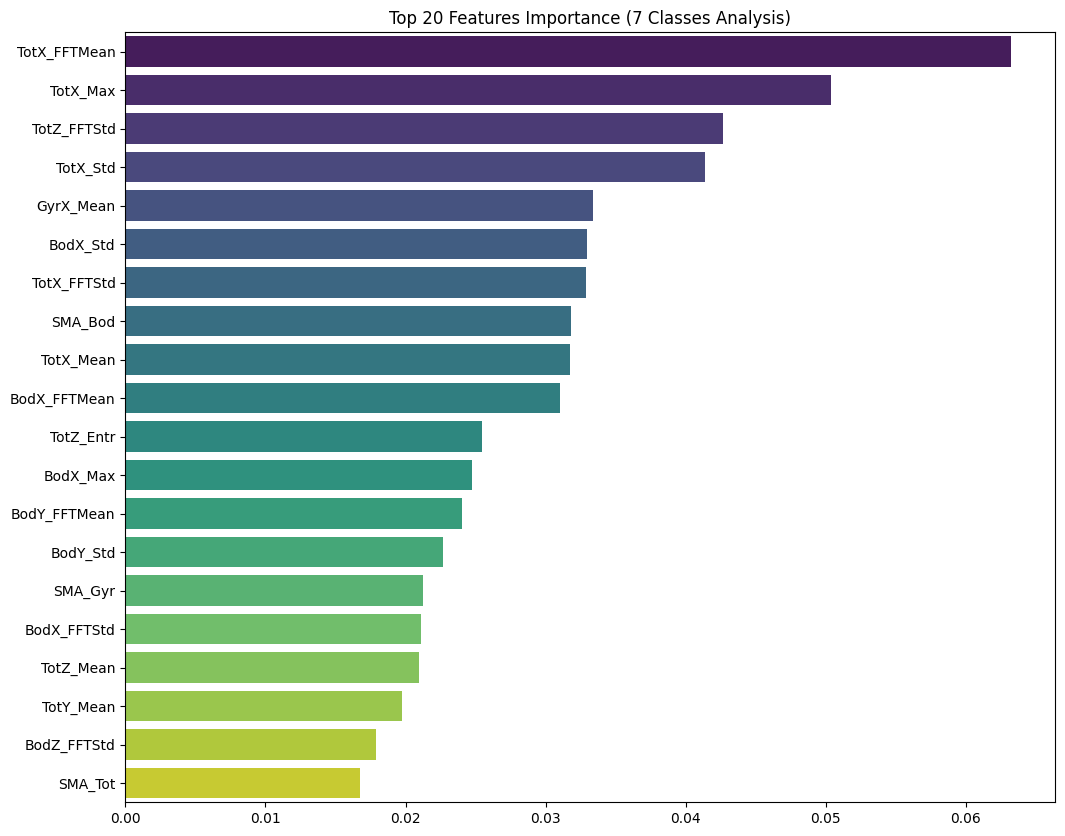

Feature importance report saved to CSV.


In [12]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy.fftpack import fft
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# =================================================================================
# PHASE 1: PRE-SUBMISSION AXIS VERIFICATION
# =================================================================================
# =================================================================================
# 1. Define and Create the specific sub-directory for 7-Class results
save_dir = "/content/drive/MyDrive/FINAL_EXPORT/RF_COMBINATION/"

if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Directory created: {save_dir}")
def verify_gravity_alignment():
    print("--- PHASE 1: GRAVITY ALIGNMENT VERIFICATION ---")
    uci_path = "/content/drive/MyDrive/old_har/har_models_30.12.2025_ucrdataset_V2/UCI HAR Dataset/train/Inertial Signals/total_acc_x_train.txt"
    try:
        uci_data = np.loadtxt(uci_path)
        uci_mean_x = np.mean(uci_data[0])
        print(f"[UCI] Mean Gravity on X-axis: {uci_mean_x:.3f} m/s^2")
    except:
        print("[UCI] Path not found. Verification skipped.")

# =================================================================================
# PHASE 2: 9-CHANNEL DATA ALIGNMENT ENGINE (Axis Swap)
# =================================================================================
def align_motionsense_9_channels(df):
    ba_x, ba_y, ba_z = df['userAcceleration.y'], -df['userAcceleration.x'], df['userAcceleration.z']
    g_x, g_y, g_z = df['gravity.y'], -df['gravity.x'], df['gravity.z']
    gy_x, gy_y, gy_z = df['rotationRate.y'], -df['rotationRate.x'], df['rotationRate.z']

    total_acc_x, total_acc_y, total_acc_z = ba_x + g_x, ba_y + g_y, ba_z + g_z

    return np.stack([
        total_acc_x, total_acc_y, total_acc_z,
        ba_x, ba_y, ba_z,
        gy_x, gy_y, gy_z
    ], axis=1)

# =================================================================================
# PHASE 3: FEATURE EXTRACTION ENGINE (75 FEATURES)
# =================================================================================
def extract_75_features(window):
    features = []
    for i in range(9):
        sig = window[:, i]
        features.extend([np.mean(sig), np.std(sig), np.max(sig), skew(sig), kurtosis(sig)])
        sig_fft = np.abs(fft(sig))[:64]
        psd = sig_fft**2 / 64
        psd_norm = psd / (np.sum(psd) + 1e-12)
        entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))
        features.extend([np.mean(sig_fft), np.std(sig_fft), entropy])

    sma_total = np.mean(np.sum(np.abs(window[:, 0:3]), axis=1))
    sma_body  = np.mean(np.sum(np.abs(window[:, 3:6]), axis=1))
    sma_gyro  = np.mean(np.sum(np.abs(window[:, 6:9]), axis=1))
    features.extend([sma_total, sma_body, sma_gyro])
    return np.array(features[:75])

# =================================================================================
# PHASE 4: COMPREHENSIVE DATA LOADING (INCLUDING JOGGING & LAYING)
# =================================================================================
def load_and_preprocess_raw_data():
    UCI_BASE = "/content/drive/MyDrive/old_har/har_models_30.12.2025_ucrdataset_V2/UCI HAR Dataset/train/"
    MS_BASE = "/content/drive/MyDrive/motion-sense-dataset/motion_sense_extracted/A_DeviceMotion_data"

    # EXTENDED TRIAL LIST - Including Jogging (jog) and Laying (lyt)
    folders = [
        'wlk_7', 'wlk_8', 'wlk_15',
        'ups_3', 'ups_4', 'ups_12',
        'dws_1', 'dws_2', 'dws_11',
        'std_6', 'std_14',
        'sit_5', 'sit_13',
        'jog_9', 'jog_16', # Added Jogging
        'lyt_1', 'lyt_2', 'lyt_10' # Added Laying
    ]

    print("Loading UCI Raw Data...")
    uci_files = ['total_acc_x_train.txt', 'total_acc_y_train.txt', 'total_acc_z_train.txt',
                 'body_acc_x_train.txt', 'body_acc_y_train.txt', 'body_acc_z_train.txt',
                 'body_gyro_x_train.txt', 'body_gyro_y_train.txt', 'body_gyro_z_train.txt']
    X_uci_raw = np.stack([np.loadtxt(os.path.join(UCI_BASE, "Inertial Signals", f)) for f in uci_files], axis=2)
    y_uci_raw = np.loadtxt(os.path.join(UCI_BASE, "y_train.txt"))

    print("Loading MotionSense Raw Data (7 Activities)...")
    ms_features, y_ms_labels = [], []
    for folder in folders:
        folder_path = os.path.join(MS_BASE, folder)
        if os.path.isdir(folder_path):
            label = folder.split('_')[0]
            csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
            for file in csv_files:
                df = pd.read_csv(os.path.join(folder_path, file))
                aligned = align_motionsense_9_channels(df)
                for start in range(0, len(aligned) - 128 + 1, 64):
                    ms_features.append(extract_75_features(aligned[start:start+128]))
                    y_ms_labels.append(label)

    return X_uci_raw, y_uci_raw, np.array(ms_features), np.array(y_ms_labels)

# =================================================================================
# PHASE 5: LABEL MAPPING AND DATA FUSION (7 CLASSES)
# =================================================================================
def fuse_and_map_datasets(X_uci_raw, y_uci_raw, X_ms_features, y_ms_labels):
    print("Fusing Datasets and Mapping 7 Labels...")
    X_uci_features = np.array([extract_75_features(w) for w in X_uci_raw])

    # Mapping for 7 Classes
    common_map = {
        'WALKING': 0, 'wlk': 0, '1': 0, '1.0': 0,
        'WALKING_UPSTAIRS': 1, 'ups': 1, '2': 1, '2.0': 1,
        'WALKING_DOWNSTAIRS': 2, 'dws': 2, '3': 2, '3.0': 2,
        'SITTING': 3, 'sit': 3, '4': 3, '4.0': 3,
        'STANDING': 4, 'std': 4, '5': 4, '5.0': 4,
        'JOGGING': 5, 'jog': 5, # Note: UCI typically doesn't have Jogging, using MS only
        'LAYING': 6, 'lyt': 6, '6': 6, '6.0': 6 # UCI label 6 is Laying
    }

    def filter_data(X, y):
        y_str = np.array([str(label).strip() for label in y])
        valid_idx = [i for i, label in enumerate(y_str) if label in common_map]
        return X[valid_idx], np.array([common_map[l] for l in y_str[valid_idx]])

    X_uci_f, y_uci_f = filter_data(X_uci_features, y_uci_raw)
    X_ms_f, y_ms_f = filter_data(X_ms_features, y_ms_labels)

    X_hybrid = np.vstack([X_uci_f, X_ms_f])
    y_hybrid = np.concatenate([y_uci_f, y_ms_f])

    np.savez_compressed("/content/drive/MyDrive/FINAL_EXPORT/RF_COMBINATION/final_hybrid_dataset_7classes.npz", X=X_hybrid, y=y_hybrid)
    return X_hybrid, y_hybrid

# =================================================================================
# PHASE 6: MODEL TRAINING
# =================================================================================
def train_hybrid_rf(X_hybrid, y_hybrid):
    print("Training Random Forest Classifier (7 Classes)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X_hybrid, y_hybrid, test_size=0.2, random_state=42, stratify=y_hybrid
    )

    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)

    joblib.dump(rf_model, "/content/drive/MyDrive/FINAL_EXPORT/RF_COMBINATION/final_hybrid_rf_model_7classes.pkl")

    y_pred = rf_model.predict(X_test)
    print("\nClassification Report (7 Classes):\n", classification_report(y_test, y_pred))
    return rf_model, X_test, y_test, y_pred


# =================================================================================
# PHASE 7: CONFUSION MATRIX VISUALIZATION (7 CLASSES)
# =================================================================================
def plot_results(y_test, y_pred):
    target_names = ['Walk', 'Upstairs', 'Downstairs', 'Sit', 'Stand', 'Jog', 'Lay']
    cm = confusion_matrix(y_test, y_pred, normalize='true')

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=target_names,
        yticklabels=target_names,
        annot_kws={"size":16}  # Font size inside cells slightly larger
    )

    # Title
    plt.title('Normalized Confusion Matrix: Hybrid Model (7 Classes)', fontsize=20)  # slightly bigger

    # Axis labels (captions) font size slightly larger
    plt.xlabel('Predicted Label', fontsize=18)  # X-axis caption
    plt.ylabel('True Label', fontsize=18)       # Y-axis caption

    # Rotate axis tick labels and increase their size
    plt.xticks(rotation=45, fontsize=16)  # Tick labels along X
    plt.yticks(rotation=45, fontsize=16)  # Tick labels along Y

    # --- Save Confusion Matrix ---
    save_path = '/content/drive/MyDrive/FINAL_EXPORT/RF_COMBINATION/confusion_matrix_7classes.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Confusion Matrix saved at: {save_path}")

    plt.show()
# =================================================================================
# PHASE 8: FEATURE IMPORTANCE ANALYSIS
# =================================================================================
def analyze_features(model):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    feat_names = []
    channels = ['TotX', 'TotY', 'TotZ', 'BodX', 'BodY', 'BodZ', 'GyrX', 'GyrY', 'GyrZ']
    stats = ['Mean', 'Std', 'Max', 'Skew', 'Kurt', 'FFTMean', 'FFTStd', 'Entr']
    for ch in channels:
        for s in stats: feat_names.append(f"{ch}_{s}")
    feat_names.extend(['SMA_Tot', 'SMA_Bod', 'SMA_Gyr'])

    plt.figure(figsize=(12, 10))
    sns.barplot(x=importances[indices[:20]], y=[feat_names[i] for i in indices[:20]], palette="viridis")
    plt.title('Top 20 Features Importance (7 Classes Analysis)')
    plt.savefig('/content/drive/MyDrive/FINAL_EXPORT/RF_COMBINATION/feature_importance_7classes.png', dpi=300)
    plt.show()

    # Save Feature Importances to CSV
    importance_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
    importance_df.sort_values(by='Importance', ascending=False).to_csv('/content/drive/MyDrive/FINAL_EXPORT/RF_COMBINATION/feature_importances_report.csv', index=False)
    print("Feature importance report saved to CSV.")

# --- EXECUTION ---
save_dir = "/content/drive/MyDrive/FINAL_EXPORT/RF_COMBINATION/"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

verify_gravity_alignment()
X_uci_r, y_uci_r, X_ms_f, y_ms_l = load_and_preprocess_raw_data()
X_h, y_h = fuse_and_map_datasets(X_uci_r, y_uci_r, X_ms_f, y_ms_l)
model, X_test, y_test, y_pred = train_hybrid_rf(X_h, y_h)
plot_results(y_test, y_pred)
analyze_features(model)

# convert rf to mlpackage

In [13]:
!pip install scikit-learn==1.5.2 coremltools pandas numpy matplotlib scipy joblib --upgrade

In [14]:
import joblib
import coremltools as ct
import os
import shutil
import numpy as np

# 1. Define Paths
PKL_PATH = '/content/drive/MyDrive/FINAL_EXPORT/RF_COMBINATION/final_hybrid_rf_model_7classes.pkl'
COREML_SAVE_PATH = '/content/drive/MyDrive/FINAL_EXPORT/RF_COMBINATION/RFActivityClassifier.mlpackage'

print(f"Loading the 75-feature model from: {PKL_PATH}")

if not os.path.exists(PKL_PATH):
    print("Error: PKL file not found. Please check the path.")
else:
    # 2. Load the trained RF model
    rf_model = joblib.load(PKL_PATH)
    print(f"Model Loaded successfully. Type: {type(rf_model)}")

    # Overwrite the classes_ array directly in the sklearn model memory
    rf_model.classes_ = np.array([str(c) for c in rf_model.classes_], dtype=object)

    # 3. Define the 75 input feature names
    feature_names = [f"feature_{i}" for i in range(75)]

    print("Converting to .mlpackage (75 Features)...")

    try:
        # 4. Conversion
        coreml_model = ct.converters.sklearn.convert(
            rf_model,
            input_features=feature_names,
            output_feature_names="classLabel"
        )

        # 5. Set Metadata
        coreml_model.author = "Amir"
        coreml_model.short_description = "75-Feature Hybrid RF Model (7 Classes) with Soft Probabilities"

        # ---------------------------------------------------------
        # THE FIX: Create the parent directory 'v' if it does not exist
        # ---------------------------------------------------------
        save_dir = os.path.dirname(COREML_SAVE_PATH)
        os.makedirs(save_dir, exist_ok=True)

        # 6. Save logic
        if os.path.exists(COREML_SAVE_PATH):
            shutil.rmtree(COREML_SAVE_PATH)

        coreml_model.save(COREML_SAVE_PATH)
        print(f"Success! .mlpackage saved at: {COREML_SAVE_PATH}")

    except Exception as e:
        print(f"An error occurred during conversion: {e}")

Loading the 75-feature model from: /content/drive/MyDrive/FINAL_EXPORT/RF_COMBINATION/final_hybrid_rf_model_7classes.pkl
Model Loaded successfully. Type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Converting to .mlpackage (75 Features)...
Success! .mlpackage saved at: /content/drive/MyDrive/FINAL_EXPORT/RF_COMBINATION/RFActivityClassifier.mlpackage
